In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "rte"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3000
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 2490
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3000
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'No Weapons of Mass Destruction Found in Iraq Yet.',
 'sentence2': 'Weapons of Mass Destruction Found in Iraq.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Britain said, Friday, that it has barred cleric, Omar Bakri, from returning to the country from Lebanon, where he was released by police after being detained for 24 hours.',
 'Bakri was briefly detained, but was released.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 3000/3000 [00:00<00:00, 30581.20 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2490
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 277
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 167]),
 'token_type_ids': torch.Size([32, 167]),
 'attention_mask': torch.Size([32, 167])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.8105, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

In [26]:
from train_eval_func import eval_loop

In [27]:
eval_loop(model, val_dataloader, task_name, device)

({'accuracy': 0.5270758122743683}, 0.8478608263863457)

# 5. Learning Rate and Leanring Scheduler Setup

In [28]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)

In [29]:
from train_eval_func import set_lr_scheduler

num_epochs = 10
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = set_lr_scheduler(
    optimizer          = optimizer,
    num_training_steps = num_training_steps
)

print(num_training_steps)

780


In [30]:
patience=3
save_path=f'./weights/bert-{task_name}.pt'

# 6. Training

In [31]:
from train_eval_func import train

In [32]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=num_epochs,
    lr=lr_scheduler,
    patience=patience,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    save_path=save_path,
    display_epoch_iter=True
)

Training:   0%|          | 0/780 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/glue_fine_tune/../train_eval_func.py:207: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 78/780 [00:29<02:30,  4.65it/s]

✓ Saved checkpoint (best loss: 0.6326)

<----------------- Epoch 1 ----------------->
Loss: 0.68, Training Metrics:
  accuracy: 0.5779
Validation Loss: 0.63, Validation Metrics:
  accuracy: 0.6534
Elapsed Time: 30.4726 sec


Training:  20%|██        | 156/780 [01:01<02:14,  4.63it/s]

✓ Saved checkpoint (best loss: 0.6282)

<----------------- Epoch 2 ----------------->
Loss: 0.47, Training Metrics:
  accuracy: 0.7859
Validation Loss: 0.63, Validation Metrics:
  accuracy: 0.6715
Elapsed Time: 19.9288 sec


Training:  30%|███       | 234/780 [01:33<01:59,  4.58it/s]

...


<----------------- Epoch 4 ----------------->
Loss: 0.12, Training Metrics:
  accuracy: 0.9614
Validation Loss: 1.14, Validation Metrics:
  accuracy: 0.6751
Elapsed Time: 20.0722 sec


Training:  50%|█████     | 390/780 [02:25<01:21,  4.81it/s]


<----------------- Epoch 5 ----------------->
Loss: 0.09, Training Metrics:
  accuracy: 0.9747
Validation Loss: 1.56, Validation Metrics:
  accuracy: 0.6787
Elapsed Time: 20.0325 sec


Training:  60%|██████    | 468/780 [02:46<01:51,  2.80it/s]


<----------------- Epoch 6 ----------------->
Loss: 0.06, Training Metrics:
  accuracy: 0.9871
Validation Loss: 2.19, Validation Metrics:
  accuracy: 0.6715
Elapsed Time: 20.2056 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 166.93 sec
Chosen Primary Metric: accuracy
Best Metric Run: 0.6859


### Plotting Loss

In [33]:
from train_eval_func import plotLoss, plotAccuracy

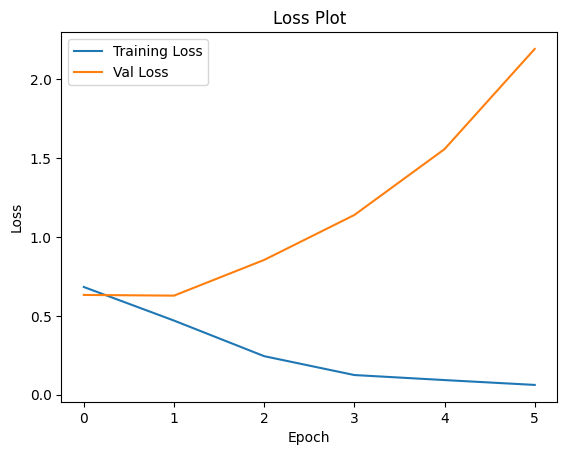

In [34]:
plotLoss(train_stats['train_losses'], train_stats['val_losses'], title="Loss Plot")

### Plotting Accuracy

In [35]:
def getMetricList(train_stats, metric_name='accuracy'):
    train_values = [m[metric_name] for m in train_stats['train_metrics_history']]
    val_values = [m[metric_name] for m in train_stats['val_metrics_history']]

    return train_values, val_values

In [36]:
train_values, val_values = getMetricList(train_stats)

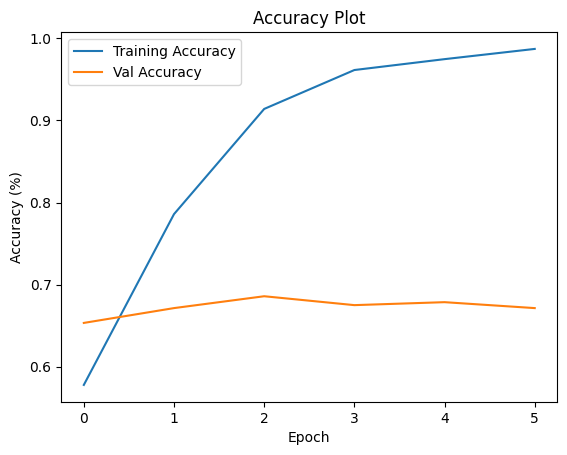

In [37]:
plotAccuracy(train_values, val_values, title="Accuracy Plot")

# 7. Evaluation

In [41]:
best_weight = torch.load(save_path)

In [42]:
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.6859205776173285}

In [44]:
best_weight['epoch']

3